## Load Uncalibrated Config

In [31]:
from pathlib import Path
import json 

DATA_FOLDER = Path('../experiments/20240508_charlie')

with open(DATA_FOLDER / 'reactor_config.json') as f: 
    cfg = json.load(f)

cfg

{'incubator_od': {'intercept': -14.706894907315895,
  'slope': 0.00024892679660541},
 'incubator_temp': {'intercept': 0, 'slope': 1},
 'lagoon_temp': {'intercept': 0, 'slope': 1},
 'incubator_stirrer_top_speed_frac': 0.24,
 'lagoon_stirrer_top_speed_frac': 0.4,
 'pumps_speed_frac': 0.4,
 'pump_incubator_to_lagoon_burst_vol_ml': 0.165,
 'pump_incubator_to_lagoon_burst_duration_s': 0.5,
 'pump_lagoon_to_waste_burst_duration_s': 0.6,
 'induction_ml_per_step': 3.674161206065187e-06}

## Temperature Calibration

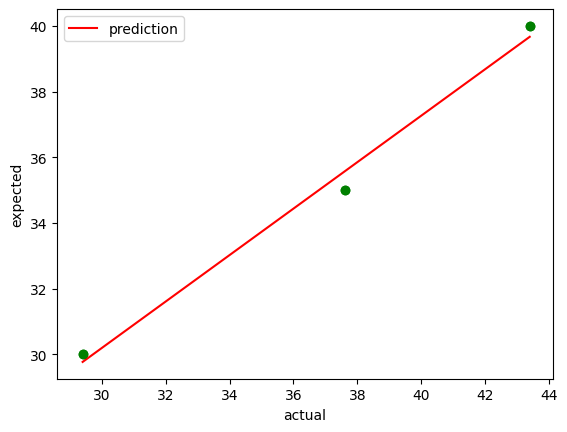

Old inc temp slope: 1.00, intercept: 0.00
New inc temp slope: 0.71, intercept: 8.97


In [57]:
from sklearn.linear_model import LinearRegression
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

def linear_fit_1d(df, x, y, show_plot=True, x_std=None, y_std=None): 
    X = df[[x]]  # Feature matrix
    Y = df[y]  # Target variable
    model = LinearRegression().fit(X, Y)
    y_pred = model.predict(X)
    slope = model.coef_[0]  # Assuming there's only one feature
    intercept = model.intercept_
    if show_plot:
        plt.scatter(df[x], df[y], color='green')
        plt.plot(df[x], y_pred, color='red', label='prediction')
        if y_std: 
            plt.errorbar(df[x], df[y], yerr=df[y_std], fmt='o', color='green')
        if x_std: 
            plt.errorbar(df[x], df[y], xerr=df[x_std], fmt='o', color='green')
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.show()
    return slope, intercept

inc_temp = pd.DataFrame({'expected': [30, 35, 40], 'actual': [29.4, 37.6, 43.4], 'actual_std': [0.1, 0.04, 0.02]})

int_temp_slope, inc_temp_intercept = linear_fit_1d(inc_temp, x='actual', y='expected', x_std='actual_std')
print(f'Old inc temp slope: {cfg["incubator_temp"]["slope"]:.2f}, intercept: {cfg["incubator_temp"]["intercept"]:.2f}')
print(f'New inc temp slope: {int_temp_slope:.2f}, intercept: {inc_temp_intercept:.2f}')


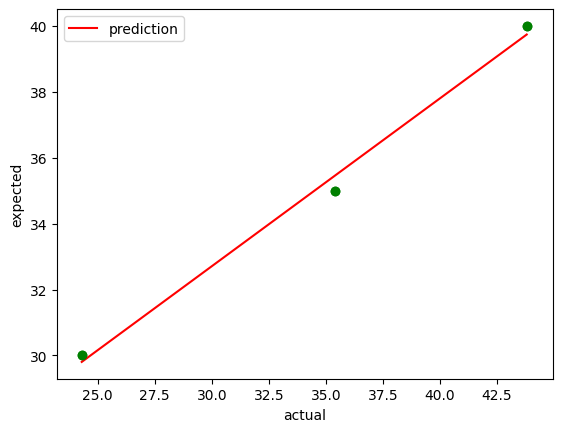

Old lagoon temp slope: 1.00, intercept: 0.00
New lagoon temp slope: 0.51, intercept: 17.42


In [58]:
lagoon_temp = pd.DataFrame({'expected': [30, 35, 40], 'actual': [24.3, 35.4, 43.8], 'actual_std': [0.1, 0.04, 0.16]})

lagoon_temp_slope, lagoon_temp_intercept =  linear_fit_1d(lagoon_temp, x='actual', y='expected', x_std='actual_std')
print(f'Old lagoon temp slope: {cfg["lagoon_temp"]["slope"]:.2f}, intercept: {cfg["lagoon_temp"]["intercept"]:.2f}')
print(f'New lagoon temp slope: {lagoon_temp_slope:.2f}, intercept: {lagoon_temp_intercept:.2f}')

## OD Calibration

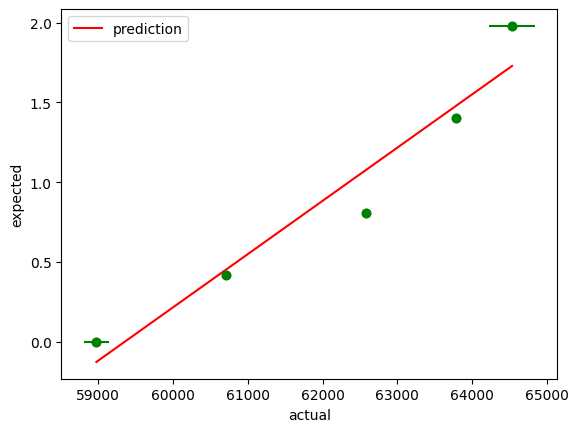

Old OD slope: 0.00025, intercept: -14.70689
New OD slope: 0.00033, intercept: -19.83591


In [52]:
measured_od = pd.read_csv(DATA_FOLDER / 'od.csv', header=None)
od_mean = measured_od.mean(axis=1)
od_std = measured_od.std(axis=1)
od = pd.DataFrame({'expected': [0.0, 0.42, 0.81, 1.4, 1.98], 'actual': od_mean, 'actual_std': od_std})

od_slope, od_intercept = linear_fit_1d(od, x='actual', y='expected', x_std='actual_std')
print(f"Old OD slope: {cfg['incubator_od']['slope']:.5f}, intercept: {cfg['incubator_od']['intercept']:.5f}")
print(f"New OD slope: {od_slope:.5f}, intercept: {od_intercept:.5f}")

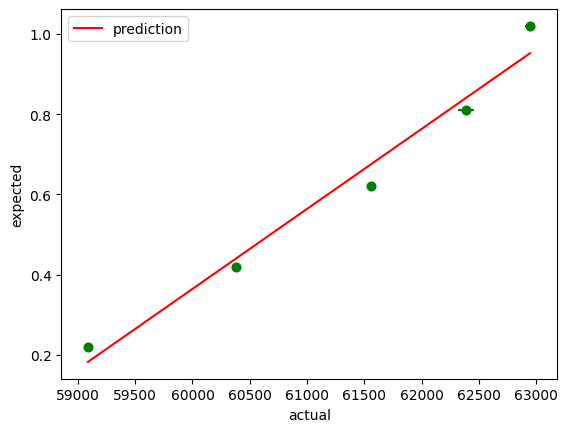

Old OD slope: 0.00025, intercept: -14.70689
New OD slope: 0.00020, intercept: -11.59206


In [53]:
measured_od = pd.read_csv(DATA_FOLDER / 'od2.csv', header=None)
od_mean = measured_od.mean(axis=1)
od_std = measured_od.std(axis=1)
od = pd.DataFrame({'expected': [0.22, 0.42, 0.62, 0.81, 1.02, 1.4], 'actual': od_mean, 'actual_std': od_std})

od_slope, od_intercept = linear_fit_1d(od.iloc[:-1, :], x='actual', y='expected', x_std='actual_std')
print(f"Old OD slope: {cfg['incubator_od']['slope']:.5f}, intercept: {cfg['incubator_od']['intercept']:.5f}")
print(f"New OD slope: {od_slope:.5f}, intercept: {od_intercept:.5f}")

## Pump Calibration

In [56]:
target_vol = 50
actual_vol = 346 - 228

expected_burst_vol = 0.165

actual_burst_vol = actual_vol / (target_vol / expected_burst_vol)
print(f'Old burst volume = {cfg["pump_incubator_to_lagoon_burst_vol_ml"]:.2f} mL')
print(f'New Burst volume = {actual_burst_vol:.2f} mL') 

Old burst volume = 0.17 mL
New Burst volume = 0.39 mL


## Update Config

In [ ]:
new_cfg = cfg.copy()
new_cfg['incubator_temp']['slope'] = int_temp_slope
new_cfg['incubator_temp']['intercept'] = inc_temp_intercept
new_cfg['lagoon_temp']['slope'] = lagoon_temp_slope
new_cfg['lagoon_temp']['intercept'] = lagoon_temp_intercept
new_cfg['incubator_od']['slope'] = od_slope
new_cfg['incubator_od']['intercept'] = od_intercept
new_cfg['pump_incubator_to_lagoon_burst_vol_ml'] = actual_burst_vol

with open(DATA_FOLDER / 'new_reactor_config.json', 'w') as f:
    json.dump(new_cfg, f)